---
title: "Intro Exercise. Explore GWAS Summary Statistics"
format:
  html:
    toc: true
    toc-depth: 3
    number-sections: true
---

# Overview

This notebook turns the original exploration script into a guided practical. You will load a large GWAS summary-statistics table, inspect its structure, apply simple quality-control filters, and generate the standard first-pass plots used in downstream interpretation.

::: {.callout-note}
## Learning goals
By the end of this notebook, you should be able to:

- Describe what a GWAS summary statistics file contains and what each column means
- Apply the standard QC filters (imputation quality, minor allele frequency) and say why each exists
- Compute and interpret the genomic inflation factor λ and λ~1000~
- Read a QQ plot and a Manhattan plot, and distinguish polygenic signal from technical inflation
- Count independent loci rather than significant SNPs
- Spot duplicate identifiers and the other structural problems that break downstream tools
:::

::: {.callout-tip}
**How to Use the Code in This Session (and the next ones)**

Run the notebook top to bottom. Every chunk depends on the ones above it.
Where you see a **Read the output** box, stop and look at what R printed
*before* reading the explanation. The whole point of this session is learning
to read GWAS output, not learning to type R.

**When do you use this?**
A collaborator sends you a GWAS summary statistics file and asks you to run a
polygenic score, a genetic correlation, or a MAGMA gene analysis. Before you run
*anything* downstream, you have to answer three questions: **Is this file
well-formed? Is the signal real or is it inflation? Which variants do I keep?**
Every method you will use for the rest of this course silently assumes you have
already done this.

**Before you run anything**
The ADHD summary-statistics file should be available at `input/ADHD2022_iPSYCH_deCODE_PGC.meta.gz`. This is the **ADHD 2022 GWAS meta-analysis** (Demontis et al., *Nature Genetics*
2023) combining iPSYCH, deCODE and the Psychiatric Genomics Consortium:
**38,691 cases and 186,843 controls**, ~6.7 million variants, genome build
**hg19 (GRCh37)**.
:::

::: {.callout-note}
** Study Questions**
Use these questions to frame the analysis before you start:

1. Which columns are essential if you want to run gene-level analyses later?
2. Why are INFO and MAF filters usually applied before visualisation or downstream modelling?
3. What would you expect a healthy null-like p-value distribution to look like?
4. Why can a very large GWAS show some QQ-plot inflation even when the analysis is not obviously flawed?
:::

In [1]:
pacman::p_load(vroom, dplyr, ggplot2, scales, qqman, data.table)

sumstats_path <- "input/ADHD2022_iPSYCH_deCODE_PGC.meta.gz"
figures_dir <- "output/figures"
dir.create(figures_dir, showWarnings = FALSE, recursive = TRUE)

## Step 1: Load the file and read the columns

`vroom()` reads gzipped files directly and is fast enough that a 6.7-million-row file loads in a few seconds.

In [2]:
sumstats <- vroom(sumstats_path, show_col_types = FALSE)

cat(sprintf("Loaded %s variants x %d columns\n",
            format(nrow(sumstats), big.mark = ","), ncol(sumstats)))

head(sumstats, 8)


glimpse(sumstats)

Loaded 6,774,224 variants x 14 columns


CHR,SNP,BP,A1,A2,FRQ_A_38691,FRQ_U_186843,INFO,OR,SE,P,Direction,Nca,Nco
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
8,rs62513865,101592213,C,T,0.925,0.937,0.981,0.99631,0.0175,0.8325,+---+++0-++-+,38691,186843
8,rs79643588,106973048,G,A,0.910,0.917,1.000,1.00411,0.0159,0.7967,++--++-+-+-++,38691,186843
8,rs17396518,108690829,T,G,0.561,0.577,0.998,0.99611,0.0096,0.6876,--++-++??-+--,37367,184388
8,rs983166,108681675,A,C,0.570,0.586,0.996,0.99491,0.0096,0.5956,--++-++++-+--,38691,186843
8,rs28842593,103044620,T,C,0.839,0.836,0.982,0.98314,0.0135,0.2081,----++0+??--+,37504,184525
8,rs7014597,104152280,G,C,0.824,0.824,0.997,0.99950,0.0122,0.9679,+-++-+++++---,38691,186843
8,rs3134156,100479917,T,C,0.841,0.833,0.997,0.98866,0.0128,0.3762,-+----+--++--,38691,186843
8,rs6980591,103144592,A,C,0.783,0.790,1.000,1.01106,0.0108,0.3075,++-++---+++++,38691,186843


Rows: 6,774,224
Columns: 14
$ CHR          <dbl> 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, …
$ SNP          <chr> "rs62513865", "rs79643588", "rs17396518", "rs983166", "rs…
$ BP           <dbl> 101592213, 106973048, 108690829, 108681675, 103044620, 10…
$ A1           <chr> "C", "G", "T", "A", "T", "G", "T", "A", "A", "C", "G", "C…
$ A2           <chr> "T", "A", "G", "C", "C", "C", "C", "C", "T", "T", "A", "T…
$ FRQ_A_38691  <dbl> 0.925, 0.910, 0.561, 0.570, 0.839, 0.824, 0.841, 0.783, 0…
$ FRQ_U_186843 <dbl> 0.937, 0.917, 0.577, 0.586, 0.836, 0.824, 0.833, 0.790, 0…
$ INFO         <dbl> 0.981, 1.000, 0.998, 0.996, 0.982, 0.997, 0.997, 1.000, 0…
$ OR           <dbl> 0.99631, 1.00411, 0.99611, 0.99491, 0.98314, 0.99950, 0.9…
$ SE           <dbl> 0.0175, 0.0159, 0.0096, 0.0096, 0.0135, 0.0122, 0.0128, 0…
$ P            <dbl> 0.832500, 0.796700, 0.687600, 0.595600, 0.208100, 0.96790…
$ Direction    <chr> "+---+++0-++-+", "++--++-+-+-++", "--++-++??-+--", "--++-…
$ Nca       

### What each column means

| Column | Meaning | Why you care |
|---|---|---|
| `CHR`, `BP` | Chromosome and base-pair position (hg19) | Every downstream tool needs a genome build; mixing hg19 and hg38 silently ruins the analysis |
| `SNP` | rsID from dbSNP | The key used to match against LD reference panels |
| `A1` | Effect allele: effects and frequencies refer to this allele | Get this wrong and every effect direction flips |
| `A2` | Other allele | Needed to harmonise across datasets |
| `FRQ_A_*`, `FRQ_U_*` | Frequency of `A1` in cases / controls | Used to derive MAF; a large case-control gap at a non-associated SNP signals a genotyping problem |
| `INFO` | Imputation quality, 0-1 | Poorly imputed variants give noisy, biased effect estimates |
| `OR` | Odds ratio per copy of `A1` | The effect size |
| `SE` | Standard error of log(OR) | Precision; `Z = log(OR)/SE` |
| `P` | Association p-value | The evidence |
| `Nca`, `Nco` | Cases and controls | Needed for effective sample size |

::: {.callout-note}
### Why frequency columns have numbers in their names
The PGC convention writes the sample size into the header: `FRQ_A_38691` = allele frequency in the 38,691 cases; `FRQ_U_186843` = frequency in the 186,843 controls.
:::

In [3]:
frq_case_col <- grep("^FRQ_A", names(sumstats), value = TRUE)
frq_ctrl_col <- grep("^FRQ_U", names(sumstats), value = TRUE)

n_cases    <- sumstats$Nca[1]
n_controls <- sumstats$Nco[1]

cat(sprintf("Case frequency column   : %s\n", frq_case_col))
cat(sprintf("Control frequency column: %s\n", frq_ctrl_col))
cat(sprintf("Cases    : %s\nControls : %s\nTotal N  : %s\n",
            format(n_cases,    big.mark = ","),
            format(n_controls, big.mark = ","),
            format(n_cases + n_controls, big.mark = ",")))

Case frequency column   : FRQ_A_38691
Control frequency column: FRQ_U_186843
Cases    : 38,691
Controls : 186,843
Total N  : 225,534


Variants per chromosome.

In [4]:
snps_per_chr <- sumstats %>%
  count(CHR, name = "n_variants") %>%
  arrange(CHR)

snps_per_chr

CHR,n_variants
<dbl>,<int>
1,522784
2,581259
3,494157
4,500139
5,447115
6,464544
7,396727
8,385938
9,289399


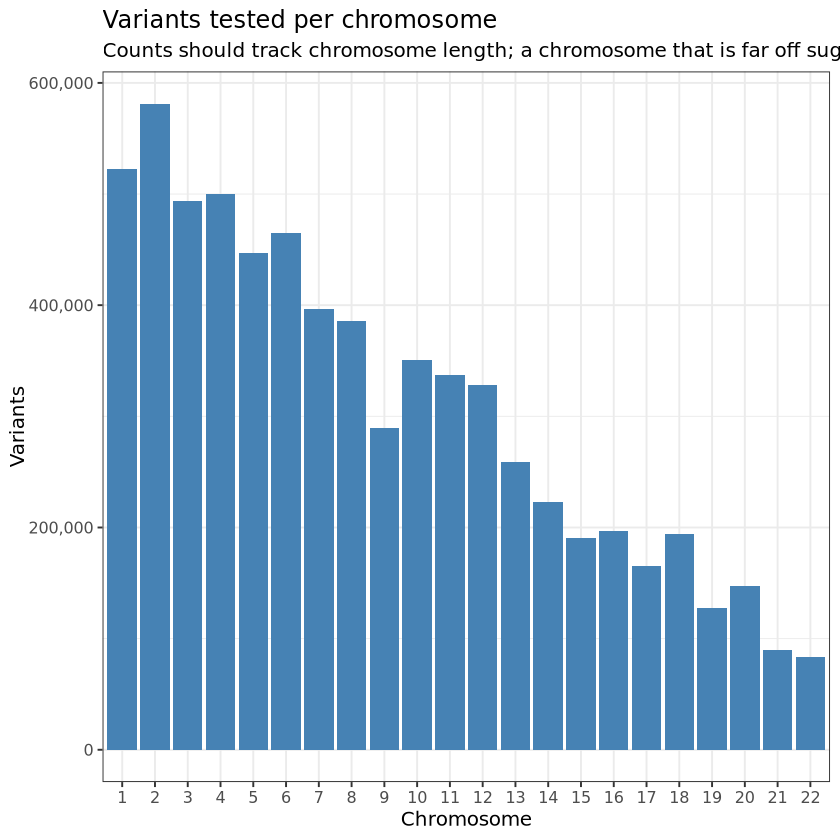

In [5]:
ggplot(snps_per_chr, aes(x = factor(CHR), y = n_variants)) +
  geom_col(fill = "#4682B4") +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Variants tested per chromosome",
       subtitle = "Counts should track chromosome length; a chromosome that is far off suggests a truncated file",
       x = "Chromosome", y = "Variants") +
  theme_bw(base_size = 12)

::: {.callout-tip}
### Read the output

The bars decline smoothly from chromosome 1 to 22, roughly in proportion to
chromosome length. That smooth decline is the check: a chromosome that is
missing, or that has far fewer variants than its neighbours, usually means the
file was truncated during download or that one chromosome failed in the
meta-analysis. Note also that the sex chromosomes are absent: this file is
autosomes only, which is typical and which MAGMA expects.
:::

## Step 2: Quality control

Two filters are near-universal in post-GWAS work.

::: {.callout-note}
### The two standard filters

1. **`INFO >= 0.8`**: keep only well-imputed variants.
   Most variants in a GWAS were never genotyped; they were *imputed* from a
   reference panel. `INFO` (also called `Rsq`) estimates how much information
   the imputation actually recovered. Below 0.8 the effect estimate is attenuated
   and the standard error is unreliable.

2. **`MAF >= 0.01`**: keep only common variants.
   At MAF < 1% the effective sample size for the minor allele is small, the
   asymptotic assumptions behind the logistic regression start to fail, and the
   LD reference panels used downstream (typically ~500 individuals) cannot
   estimate LD for the variant at all.
:::

**MAF** (minor allele frequency) is not in the file, so we derive it. The
frequency columns report the frequency of `A1`, which may be the major or the
minor allele; the minor allele frequency is whichever of the two is smaller.

In [6]:
sumstats <- sumstats %>%
  mutate(MAF = pmin(.data[[frq_case_col]], 1 - .data[[frq_case_col]]))

sumstats_qc <- sumstats %>%
  filter(INFO >= 0.8, MAF >= 0.01)

n_variants_raw <- nrow(sumstats)

qc_table <- tibble(
  Step = c("Variants in file",
           "Fail INFO < 0.8",
           "Fail MAF < 0.01",
           "Pass both (analysis set)"),
  Variants = c(nrow(sumstats),
               sum(sumstats$INFO < 0.8, na.rm = TRUE),
               sum(sumstats$MAF  < 0.01, na.rm = TRUE),
               nrow(sumstats_qc))
) %>%
  mutate(`% of file` = sprintf("%.1f%%", 100 * Variants / nrow(sumstats)),
         Variants = format(Variants, big.mark = ","))

qc_table

Step,Variants,% of file
<chr>,<chr>,<chr>
Variants in file,"6,774,224",100.0%
Fail INFO < 0.8,0,0.0%
Fail MAF < 0.01,99,0.0%
Pass both (analysis set),"6,774,125",100.0%


::: {.callout-warning}
### These two counts overlap

The INFO row and the MAF row are **not** mutually exclusive, because rare
variants are also the hardest to impute, so many variants fail both filters. This is why the
three numbers do not add up, and why you should always report the size of the
final analysis set rather than a list of exclusions.
:::

### Look at what you are filtering on

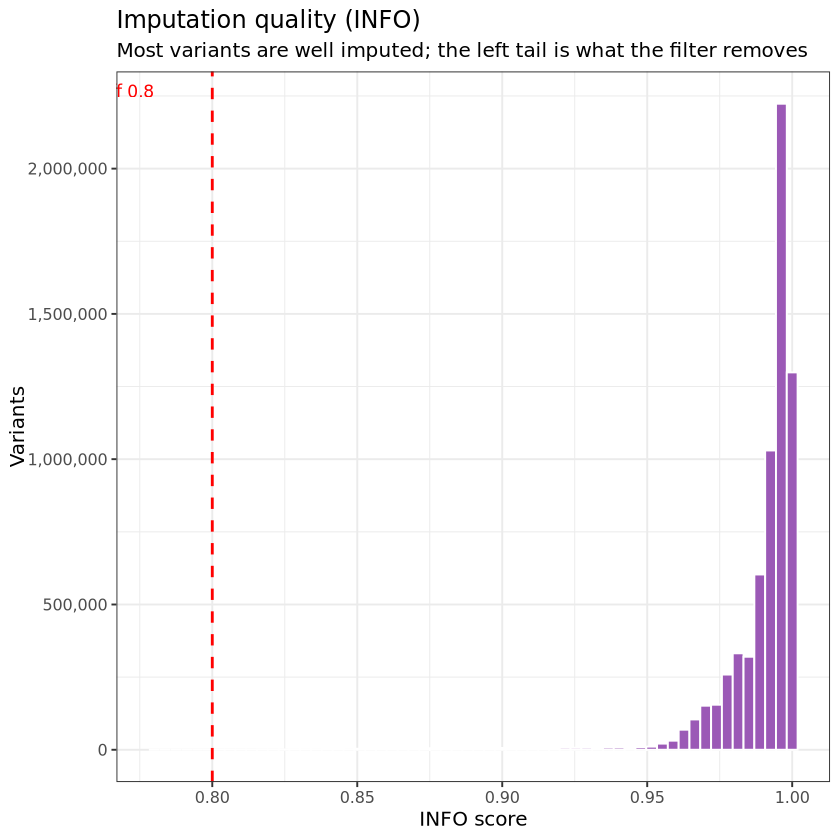

In [7]:
sumstats %>%
  filter(INFO <= 1) %>%
  ggplot(aes(x = INFO)) +
  geom_histogram(bins = 60, fill = "#9B59B6", colour = "white") +
  geom_vline(xintercept = 0.8, linetype = "dashed", colour = "red", linewidth = 0.8) +
  annotate("text", x = 0.78, y = Inf, label = "cut-off 0.8",
           vjust = 2, hjust = 1, colour = "red", size = 3.6) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Imputation quality (INFO)",
       subtitle = "Most variants are well imputed; the left tail is what the filter removes",
       x = "INFO score", y = "Variants") +
  theme_bw(base_size = 12)

That was the last plot that needs the pre-QC data. Holding both the full file
and the QC-passing subset in memory costs several gigabytes, so we drop the
larger one now. Everything below works from `sumstats_qc`.

In [8]:
rm(sumstats)
invisible(gc())

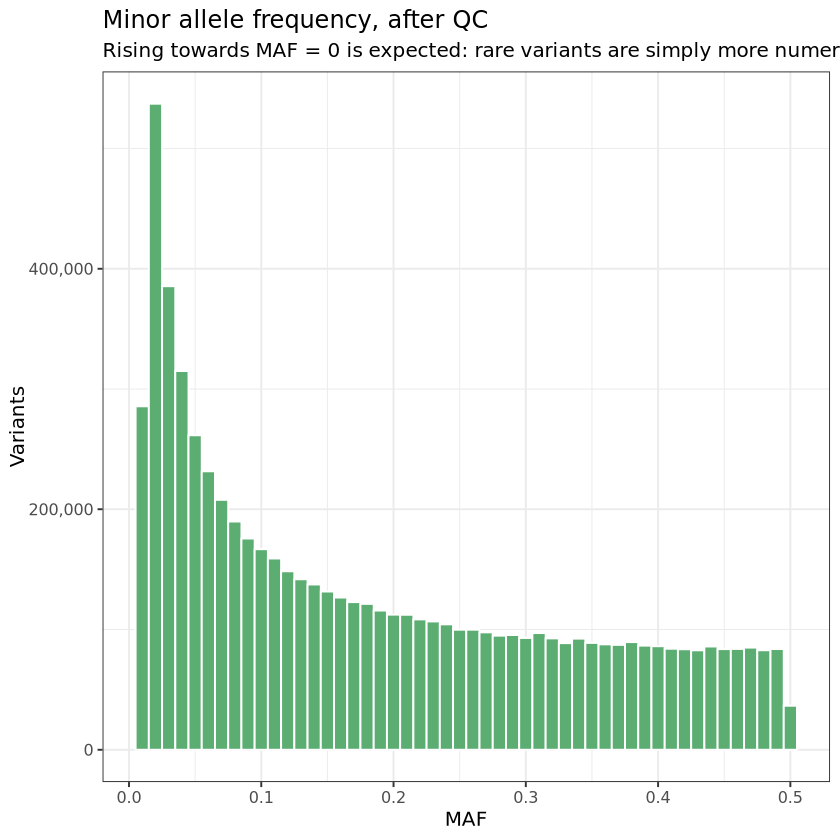

In [9]:
ggplot(sumstats_qc, aes(x = MAF)) +
  geom_histogram(bins = 50, fill = "#5BAD72", colour = "white") +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Minor allele frequency, after QC",
       subtitle = "Rising towards MAF = 0 is expected: rare variants are simply more numerous",
       x = "MAF", y = "Variants") +
  theme_bw(base_size = 12)

::: {.callout-tip}
### Read the output

**INFO:** a tall spike at 1.0 (directly genotyped or perfectly imputed variants)
with a thin tail towards 0. A file where the *bulk* of the mass sits below 0.8
was imputed against the wrong or an under-powered reference panel and should be
sent back to whoever produced it.

**MAF:** the counts rise steeply as MAF approaches the 0.01 boundary. This is the
site frequency spectrum (most variation in the genome is rare), not a problem.
What *would* be a problem is a gap or a spike at a particular frequency, which
signals a merge of two panels with different variant sets.
:::

### Distributions of the key columns

In [10]:
sumstats_qc %>%
  select(P, OR, SE, INFO, MAF) %>%
  summary()

       P                OR               SE               INFO       
 Min.   :0.0000   Min.   :0.8127   Min.   :0.00800   Min.   :0.8020  
 1st Qu.:0.1826   1st Qu.:0.9884   1st Qu.:0.01030   1st Qu.:0.9870  
 Median :0.4381   Median :0.9999   Median :0.01340   Median :0.9950  
 Mean   :0.4549   Mean   :1.0001   Mean   :0.01776   Mean   :0.9893  
 3rd Qu.:0.7159   3rd Qu.:1.0114   3rd Qu.:0.02180   3rd Qu.:0.9980  
 Max.   :1.0000   Max.   :1.3148   Max.   :0.08480   Max.   :1.0200  
      MAF        
 Min.   :0.0100  
 1st Qu.:0.0520  
 Median :0.1490  
 Mean   :0.1864  
 3rd Qu.:0.3050  
 Max.   :0.5000  

## Step 3: Is the signal real? λ and the QQ plot

Under the null, p-values are uniform on (0,1). The genomic inflation factor $\lambda$ measures how far the observed distribution has shifted.

In [11]:
chisq_obs <- qchisq(1 - sumstats_qc$P, df = 1)

lambda_gc  <- median(chisq_obs, na.rm = TRUE) / qchisq(0.5, df = 1)
N_total    <- n_cases + n_controls
lambda1000 <- 1 + (lambda_gc - 1) * (1000 / N_total)

cat(sprintf("lambda      : %.4f\n", lambda_gc))
cat(sprintf("lambda_1000 : %.4f\n", lambda1000))

lambda      : 1.3216
lambda_1000 : 1.0014


::: {.callout-important}
### λ > 1 does not mean your GWAS is broken

This is the single most common misreading in the field.

λ is inflated by **two** things: technical artefacts (population stratification,
cryptic relatedness, batch effects) **and** genuine polygenicity. For a highly
polygenic trait measured in 225,000 people, thousands of true small effects push
the *whole* p-value distribution left, and λ rises for entirely legitimate
reasons.

**λ~1000~** removes the sample-size component by rescaling to N = 1000 per group.
Look at the two numbers printed above: a clearly elevated λ sitting alongside a
λ~1000~ of essentially 1 is the signature of polygenic signal, not
stratification.

The definitive test is **LD Score regression**: it splits inflation into a
polygenic slope and a confounding intercept. An intercept near 1 clears the
study. You will do this later in the course.
:::

The QQ plot itself takes a couple of minutes to draw over 5 million points, so
the version below was generated once with exactly this code and is read back in.
Run the chunk yourself if you want to regenerate it.

saved in output/figures/


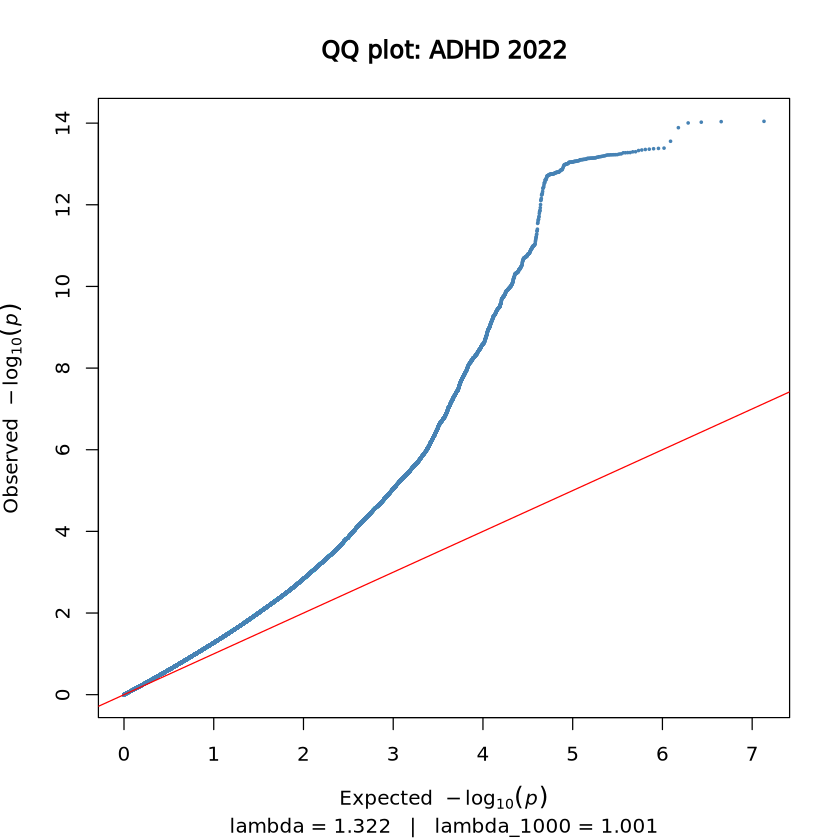

In [12]:
qq(sumstats_qc$P,
   main = "QQ plot: ADHD 2022",
   col  = "#4682B4",
   cex  = 0.4,
   sub  = sprintf("lambda = %.3f   |   lambda_1000 = %.3f", lambda_gc, lambda1000))

cat("saved in output/figures/\n")

::: {.callout-tip}
### Read the output

Read a QQ plot from **left to right**:

- **Left end (small −log10 P):** points sit *on* the diagonal. This is the
  overwhelming majority of variants, and it is what tells you there is no gross
  technical inflation. If the points lift off the line immediately at the left
  end, you have a systematic problem.
- **Right end (large −log10 P):** points peel sharply **above** the diagonal.
  These are the true associations. In a well-powered polygenic GWAS the departure
  is large and starts early; that early departure is signal, not artefact.
:::

## Step 4: The Manhattan plot

The histogram tells you that there is signal. The Manhattan plot tells you where it is.

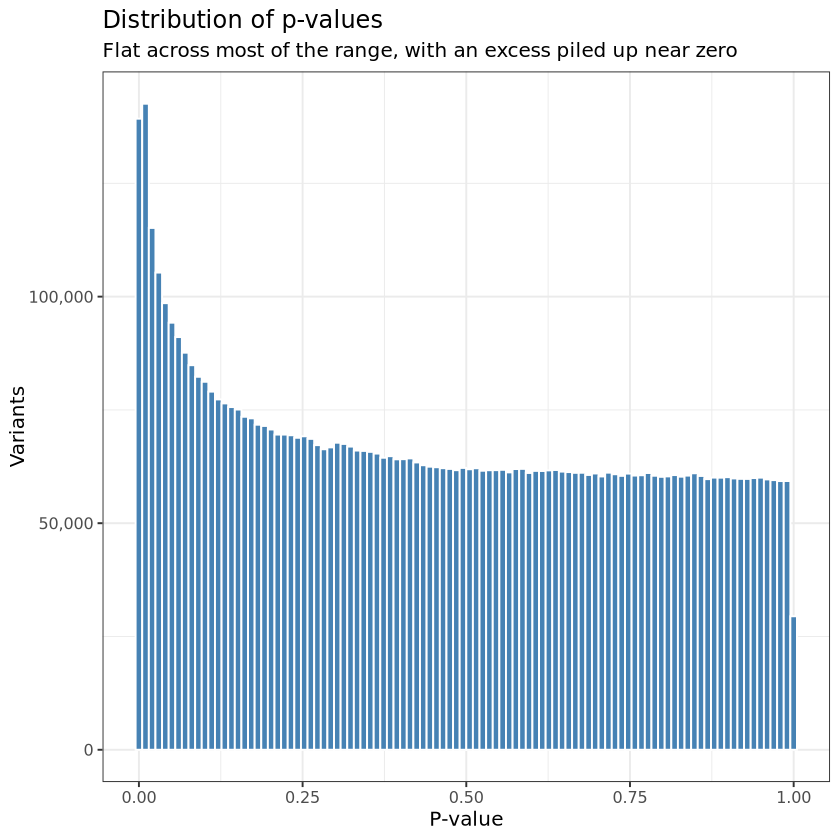

In [13]:
#| fig-height: 4.5
ggplot(sumstats_qc, aes(x = P)) +
  geom_histogram(bins = 100, fill = "#4682B4", colour = "white") +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Distribution of p-values",
       subtitle = "Flat across most of the range, with an excess piled up near zero",
       x = "P-value", y = "Variants") +
  theme_bw(base_size = 12)

In [14]:
GW_THRESH <- 5e-8   # 0.05 / 1,000,000 independent common variants

Like the QQ plot, this one is slow to draw and is read back in from a previous
run of the same code.

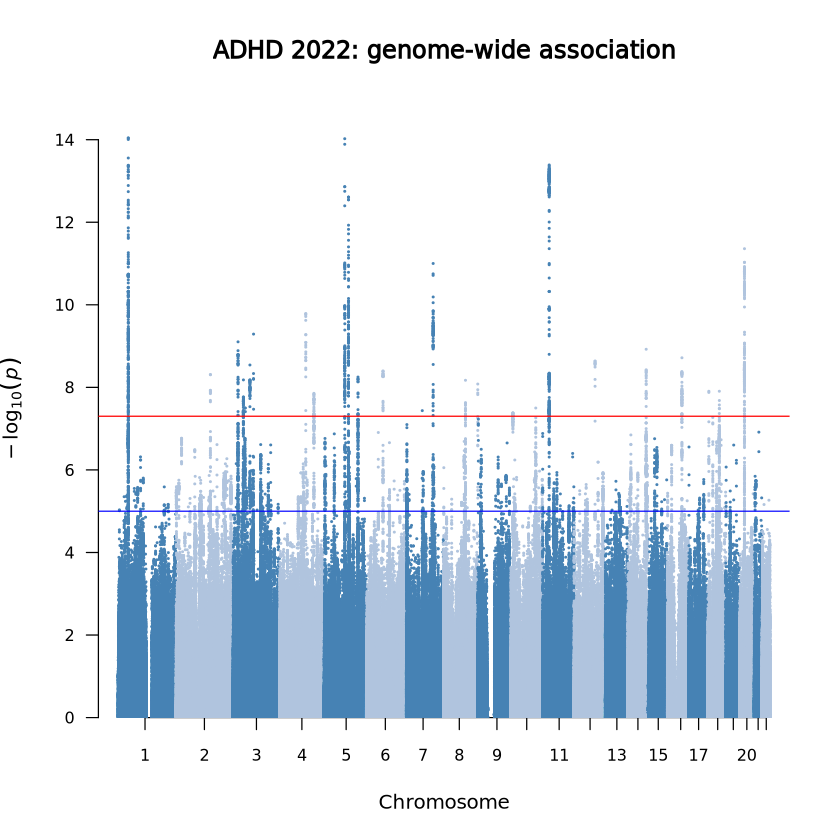

In [15]:
manhattan_data <- sumstats_qc %>%
  filter(CHR %in% 1:22) %>%
  select(CHR, BP, P, SNP)

manhattan(manhattan_data,
          chr = "CHR", bp = "BP", p = "P", snp = "SNP",
          main = "ADHD 2022: genome-wide association",
          col  = c("#4682B4", "#B0C4DE"),
          suggestiveline = -log10(1e-5),
          genomewideline = -log10(5e-8),
          cex = 0.3, cex.axis = 0.8)

::: {.callout-note}
### Where 5 × 10⁻⁸ comes from

It is a Bonferroni correction: `0.05 / 1,000,000`. The million is not the number
of variants tested (6.7 million here) but the approximate number of
**independent** common variants in a European genome, because variants in tight
LD are not independent tests. The threshold is therefore a fixed convention rather than
a per-study calculation, which is what makes it comparable across GWAS.
:::

### Count loci, not SNPs

A single association signal produces hundreds of significant SNPs, because
everything in LD with the causal variant is also significant. Reporting the raw
SNP count massively overstates the number of findings.

Proper LD-based clumping needs an LD reference panel. A good
approximation, and the one used to report locus counts in most papers, is
**distance-based collapsing**: take the most significant SNP, remove everything
within ±250 kb, repeat.



In [16]:
invisible(gc())

In [17]:
hits <- sumstats_qc %>%
  filter(P < GW_THRESH) %>%
  arrange(P)

collapse_to_loci <- function(hits, window = 250000) {
  dt <- as.data.table(hits)

  keep <- logical(nrow(dt))

  for (chr in unique(dt$CHR)) {
    idx <- which(dt$CHR == chr)
    bp <- dt$BP[idx]

    active <- rep(TRUE, length(idx))

    for (j in seq_along(idx)) {
      if (!active[j]) next

      keep[idx[j]] <- TRUE
      active <- active & abs(bp - bp[j]) > window
    }
  }

  dt[keep]
}

lead_snps <- collapse_to_loci(hits)

cat(sprintf("Genome-wide significant SNPs : %s\n", format(nrow(hits), big.mark = ",")))
cat(sprintf("Independent loci (+/-250 kb) : %d\n", nrow(lead_snps)))



lead_snps %>%
  transmute(CHR, SNP, BP,
            A1, A2,
            MAF  = round(MAF, 3),
            OR   = round(OR, 4),
            SE   = round(SE, 4),
            P    = signif(P, 3),
            INFO = round(INFO, 3),
            Direction) %>%
arrange(P)


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




Genome-wide significant SNPs : 1,428
Independent loci (+/-250 kb) : 34


CHR,SNP,BP,A1,A2,MAF,OR,SE,P,INFO,Direction
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,rs549845,44076469,G,A,0.321,1.0820,0.0102,9.03e-15,0.999,---+-----+---
5,rs4916723,87854395,A,C,0.447,0.9182,0.0110,9.48e-15,0.957,--?-++--+-+++
11,rs2582895,28602173,C,A,0.366,1.0752,0.0096,4.09e-14,1.000,--------+----
5,rs77960,103964585,G,A,0.335,0.9294,0.0100,2.46e-13,0.996,++++--+++++--
20,rs6082363,21250843,T,C,0.296,1.0728,0.0101,4.38e-12,0.999,++++---+--+-+
7,rs9969232,114158954,G,A,0.344,0.9340,0.0100,9.98e-12,0.997,++++++-+?+-+-
1,rs2527776,44345292,G,A,0.274,1.0718,0.0106,6.02e-11,1.000,---------+--+
5,rs188582,88167740,G,C,0.465,1.0613,0.0093,1.62e-10,0.999,-------------
4,rs17576773,112217523,C,T,0.112,1.1011,0.0151,1.62e-10,0.999,----+---?-++-


::: {.callout-tip}
### Read the output

Three things to check in this table before you trust a locus:

- **`Direction`**: all `+` or all `-` means every contributing cohort agrees.
  A top hit with mixed signs is heterogeneous and deserves scrutiny.
- **`INFO`**: a genome-wide significant hit with INFO near 0.8 is imputed, not
  genotyped, and is a weaker candidate than one at INFO ≈ 1.
- **`OR`**: for a common psychiatric trait these sit close to 1 (roughly
  0.94-1.07). An OR of 1.5 at MAF 0.3 in a sample this size would be
  extraordinary, and in practice usually means a strand or allele-coding error.
:::



## Step 5: Effect Sizes, Frequency, and Power

Warning message:
“Removed 1718 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_bar()`).”


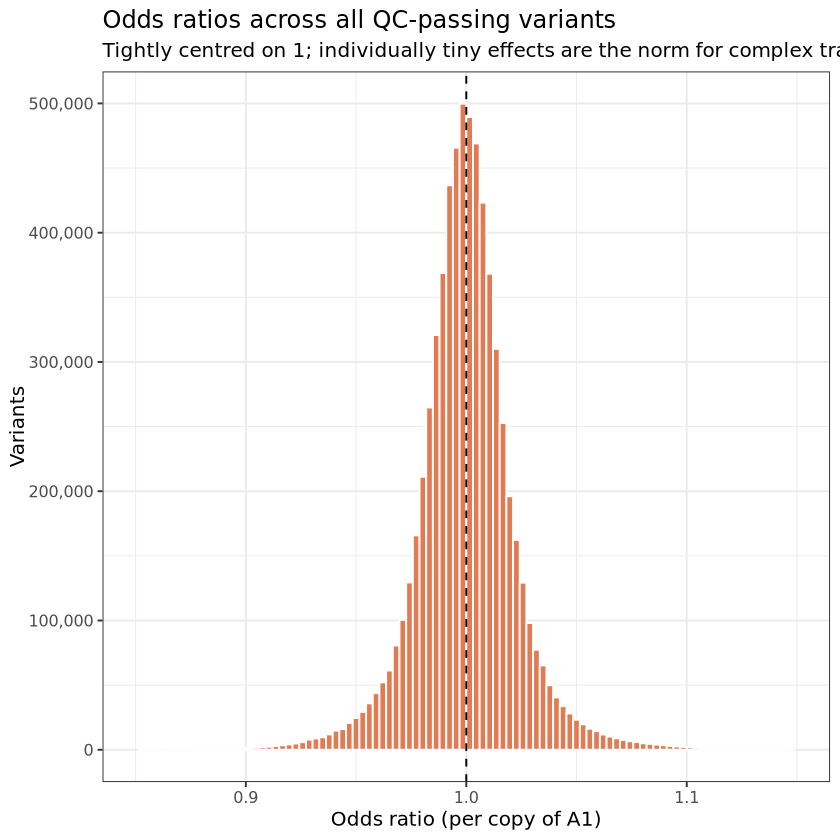

In [18]:
ggplot(sumstats_qc, aes(x = OR)) +
  geom_histogram(bins = 100, fill = "#E07B54", colour = "white") +
  geom_vline(xintercept = 1, linetype = "dashed") +
  scale_x_continuous(limits = c(0.85, 1.15)) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Odds ratios across all QC-passing variants",
       subtitle = "Tightly centred on 1; individually tiny effects are the norm for complex traits",
       x = "Odds ratio (per copy of A1)", y = "Variants") +
  theme_bw(base_size = 12)

The distribution above is *symmetric* around 1 because most variants have no
effect. The interesting question is what the *significant* variants look like as
a function of frequency.

`geom_smooth()` using formula = 'y ~ x'


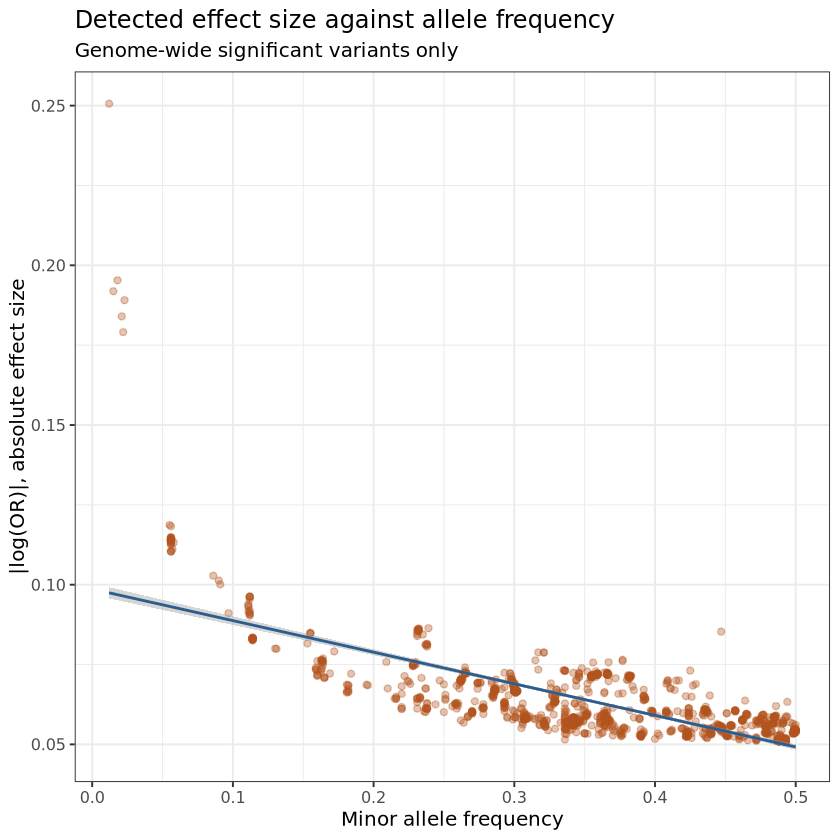

In [19]:
ggplot(hits, aes(x = MAF, y = abs(log(OR)))) +
  geom_point(alpha = 0.35, colour = "#B3541E") +
  geom_smooth(method = "lm", se = TRUE, colour = "#2c5d8f", linewidth = 0.8) +
  labs(title = "Detected effect size against allele frequency",
       subtitle = "Genome-wide significant variants only",
       x = "Minor allele frequency",
       y = "|log(OR)|, absolute effect size") +
  theme_bw(base_size = 12)

::: {.callout-tip}
### Read the output

The fitted line slopes **downward**: among the variants we detected, the rarer
ones have larger effects. This is not biology; it is a **power boundary**.
Power depends on MAF and effect size jointly, so a rare variant only clears
5 × 10⁻⁸ if its effect is large, while a common variant can clear it with a
small one. Everything below the detection boundary is invisible to us, so the
plot shows the edge of what this sample size could find, not the true
relationship between frequency and effect.

This is exactly why gene-level methods such as MAGMA exist: they aggregate the
many sub-threshold common variants inside a gene into a single test, recovering
signal that no individual variant here is powered to show.
:::

## Step 6: One Last Check on Duplicate Identifiers

Every downstream tool matches variants by rsID. Meta-analysed files routinely
contain repeated identifiers: multi-allelic sites, and rsIDs that dbSNP merged
after the study was run. Depending on the tool, duplicates cause an outright
failure or, worse, silent double-counting.

In [20]:
n_dup <- sum(duplicated(sumstats_qc$SNP))

cat(sprintf("QC-passing variants : %s\n", format(nrow(sumstats_qc), big.mark = ",")))
cat(sprintf("Duplicated rsIDs    : %s\n", format(n_dup, big.mark = ",")))

sumstats_qc %>%
  filter(SNP %in% SNP[duplicated(SNP)]) %>%
  arrange(SNP) %>%
  select(CHR, SNP, BP, A1, A2, OR, P) %>%
  head(6)

QC-passing variants : 6,774,125
Duplicated rsIDs    : 6


CHR,SNP,BP,A1,A2,OR,P
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
8,.,114316970,T,A,1.03800,0.5096
13,.,40934898,T,C,0.99203,0.9152
5,.,3443528,T,C,0.99501,0.9015
7,.,110198508,A,G,0.97297,0.3930
5,.,66547525,A,G,1.02603,0.5645
14,.,30833762,T,C,1.01096,0.8974


::: {.callout-tip}
### Read the output

Look at the duplicated rows: same rsID, same position, **different alleles**.
These are multi-allelic sites where more than one alternative allele was tested,
each written as its own row under the same identifier.

There is no universally right fix. Keeping the first row, keeping the most
significant, or dropping duplicates entirely are all defensible. What is *not*
defensible is not checking. Whatever you choose, apply it before the analysis and
state it in your Methods.
:::

### Session summary


In [21]:
tibble(
  Item = c("Dataset", "Genome build", "Variants in file", "Variants after QC",
           "Cases", "Controls", "Genome-wide significant SNPs",
           "Independent loci", "lambda", "lambda_1000",
           "Median OR", "Median MAF", "Median INFO"),
  Value = c(
    "ADHD 2022 (iPSYCH + deCODE + PGC)",
    "hg19 / GRCh37",
    format(n_variants_raw,    big.mark = ","),
    format(nrow(sumstats_qc), big.mark = ","),
    format(n_cases,           big.mark = ","),
    format(n_controls,        big.mark = ","),
    format(nrow(hits),        big.mark = ","),
    as.character(nrow(lead_snps)),
    sprintf("%.4f", lambda_gc),
    sprintf("%.4f", lambda1000),
    sprintf("%.4f", median(sumstats_qc$OR,   na.rm = TRUE)),
    sprintf("%.4f", median(sumstats_qc$MAF,  na.rm = TRUE)),
    sprintf("%.4f", median(sumstats_qc$INFO, na.rm = TRUE))
  )
)

Item,Value
<chr>,<chr>
Dataset,ADHD 2022 (iPSYCH + deCODE + PGC)
Genome build,hg19 / GRCh37
Variants in file,"6,774,224"
Variants after QC,"6,774,125"
Cases,"38,691"
Controls,"186,843"
Genome-wide significant SNPs,"1,428"
Independent loci,34
lambda,1.3216


## What can go wrong

::: {.callout-caution}
### Genome build mismatch
The single most damaging and silent error. `BP` positions here are hg19.
:::

::: {.callout-caution}
### Effect allele confusion
`A1` is the effect allele in this file. Harmonising by rsID without checking the alleles flips effect directions for roughly half the variants.
:::

::: {.callout-caution}
### Ancestry mismatch with the LD reference
This is a European-ancestry meta-analysis, so the LD reference should match ancestry.
:::

::: {.callout-caution}
### Treating λ as a pass/fail test
A high λ in a large polygenic GWAS is not automatically a problem. Use $\lambda_{1000}$ and LD score regression before concluding anything about stratification.
:::